## Introduction
So far we have completed the ETL process for our Coffee Shop Sales Product and we also build a simple regression model that we can use to predict sales per day.

We will now build a random forest model that we will use to uncover the most important features that affect our revenue.

## Objectives

 - Use scikit-learn to build a model to solve a regression problem.
 - Implement a pipeline to combine our preprocessing steps with a machine learning model
 - Interpret the results of our modelling
 - Update our pipeline with a different machine learning model such as a multiple regression model.
 - Compare the preformances of our models.
 - Uncover the most important features from our better performing model.

### Install the required libraries

In [114]:
#!pip install numpy
#!pip install matplotlib
#!pip install pandas
#!pip install scikit-learn
#!pip install seaborn
!pip install xgboost==2.1.3

### Import the required libraries

In [115]:
from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error
from sklearn import linear_model
import psycopg2
from psycopg2 import OperationalError
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

import warnings
warnings.filterwarnings('ignore')

<div id="dataset_analysis">
    <h2>Dataset Analysis</h2>
</div>

We will now import our data from our OLAP (PostgreSQL) database. We created a view called coffee_sales_data_data_science_view which we'll use as our data source. We can always backdate data from our OLTP (MySQL) -> OLAP (PostgreSQL) -> View then import the data whenever we need more training data.

In [31]:
DB_HOST = "localhost"
DB_NAME = "coffee_sales_data"
DB_USER = "postgres"
DB_PASSWORD = "Whatsnew2711"
DB_PORT = "5432"

def load_data_from_view(view_name):
    """
    Connects to a PostgreSQL database and loads a view into a pandas DataFrame.
    """
    conn = None
    df = None
    try:
        print("Connecting to the PostgreSQL database...")
        conn = psycopg2.connect(
            host=DB_HOST,
            database=DB_NAME,
            user=DB_USER,
            password=DB_PASSWORD,
            port=DB_PORT
        )
        print("Connection successful. Loading data from view...")
        sql_query = f"SELECT * FROM {view_name};"
        df = pd.read_sql(sql_query, conn)
        print(f"Data successfully loaded from '{view_name}' into a DataFrame.")
        return df

    except OperationalError as e:
        print(f"The error '{e}' occurred")
        return None
        
    finally:
        if conn is not None:
            conn.close()
            print("Database connection closed.")

In [33]:
# The view name from our database schema
target_view = "coffee_sales_data_data_science_view"

# Call the function to load the data
sales_df = load_data_from_view(target_view)

Connecting to the PostgreSQL database...
Connection successful. Loading data from view...
Data successfully loaded from 'coffee_sales_data_data_science_view' into a DataFrame.
Database connection closed.


In [35]:

if sales_df is not None:
    print("\nFirst 5 rows of the DataFrame:")
    print(sales_df.head())
    print("\nDataFrame info:")
    sales_df.info()


First 5 rows of the DataFrame:
  transaction_id  transaction_qty  total_amount transaction_date  day  month  \
0     1_20250101                2          90.0       2025-01-01    1      1   
1    10_20250101                2         105.0       2025-01-01    1      1   
2   100_20250101                2         142.5       2025-01-01    1      1   
3   101_20250101                1          45.0       2025-01-01    1      1   
4   102_20250101                2          75.0       2025-01-01    1      1   

   year    weekday transaction_time  hour  minute  second    product_category  \
0  2025  Wednesday         07:06:11     7       6      11              Coffee   
1  2025  Wednesday         07:39:34     7      39      34  Drinking Chocolate   
2  2025  Wednesday         10:49:51    10      49      51  Drinking Chocolate   
3  2025  Wednesday         10:51:17    10      51      17                 Tea   
4  2025  Wednesday         10:52:44    10      52      44              Coffee   



Each row in the dataset represents a sale. As we can see above, we have 16 variables. Our target variable will be total_amount which is basically unit_price * transaction_qty is our revenue. The objective is to build a model that will predict total_amount. Notice that transaction_date & transaction_time are both broken down into their granular levels and thus we won't need these variables

In [38]:
sales_df.drop(['transaction_date', 'transaction_time'], axis=1, inplace=True)

Let's see how our data looks now

In [40]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376033 entries, 0 to 376032
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    376033 non-null  object 
 1   transaction_qty   376033 non-null  int64  
 2   total_amount      376033 non-null  float64
 3   day               376033 non-null  int64  
 4   month             376033 non-null  int64  
 5   year              376033 non-null  int64  
 6   weekday           376033 non-null  object 
 7   hour              376033 non-null  int64  
 8   minute            376033 non-null  int64  
 9   second            376033 non-null  int64  
 10  product_category  376033 non-null  object 
 11  product_type      376033 non-null  object 
 12  product_detail    376033 non-null  object 
 13  unit_price        376033 non-null  float64
 14  store_location    376033 non-null  object 
dtypes: float64(2), int64(7), object(6)
memory usage: 43.0+ MB


We can observe that we have some object variables which are strings but now we'll be doing regression and we need these variables encoded properly so we'll perform a transformation and one hot encode these variables.

We will start by building, evaluating then extracting important features from multiple linear regression. This model only requires continuous variables and thus we'll drop all categorical variables

In [42]:
reg_sales_df = sales_df.drop(['transaction_id', 'weekday', 'product_category', 'product_type', 'product_detail', 'store_location'],axis=1)

In [44]:
#data that will be used for our multiple linear regression model
reg_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376033 entries, 0 to 376032
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   transaction_qty  376033 non-null  int64  
 1   total_amount     376033 non-null  float64
 2   day              376033 non-null  int64  
 3   month            376033 non-null  int64  
 4   year             376033 non-null  int64  
 5   hour             376033 non-null  int64  
 6   minute           376033 non-null  int64  
 7   second           376033 non-null  int64  
 8   unit_price       376033 non-null  float64
dtypes: float64(2), int64(7)
memory usage: 25.8 MB


Now that we have eliminated some features, we'll take a look at the relationships among the remaining features. 

Analyzing a correlation matrix that displays the pairwise correlations between all features indicates the level of independence between them. 

It also indicates how predictive each feature is of the target. 

You want to eliminate any strong dependencies or correlations between features by selecting the best one from each correlated group.

<Axes: >

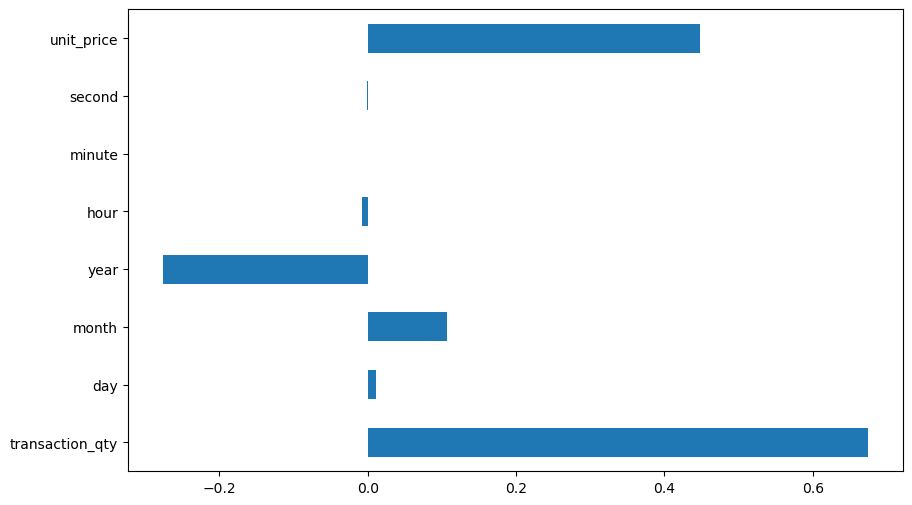

In [46]:
correlation_values = reg_sales_df.corr()['total_amount'].drop('total_amount')
correlation_values.plot(kind='barh', figsize=(10, 6))

In [48]:
reg_sales_df.corr()

,transaction_qty,total_amount,day,month,year,hour,minute,second,unit_price
transaction_qty,1.000000,0.674107,0.011744,0.137884,-0.356309,-0.006744,-0.000280,-0.000856,-0.058795
total_amount,0.674107,1.000000,0.011542,0.106507,-0.275735,-0.008178,0.000493,-0.000517,0.448105
day,0.011744,0.011542,1.000000,0.005464,-0.006676,-0.029473,0.000458,-0.001111,0.014427
month,0.137884,0.106507,0.005464,1.000000,-0.385134,-0.007901,-0.002055,-0.002511,-0.009711
year,-0.356309,-0.275735,-0.006676,-0.385134,1.000000,0.018415,0.003957,0.004052,0.020587
hour,-0.006744,-0.008178,-0.029473,-0.007901,0.018415,1.000000,-0.009960,-0.003181,-0.005587
minute,-0.000280,0.000493,0.000458,-0.002055,0.003957,-0.009960,1.000000,-0.004948,0.003476
second,-0.000856,-0.000517,-0.001111,-0.002511,0.004052,-0.003181,-0.004948,1.000000,0.000151
unit_price,-0.058795,0.448105,0.014427,-0.009711,0.020587,-0.005587,0.003476,0.000151,1.000000


We can see that minute and second have a very low correlation and thus we'll drop these variables

In [50]:
reg_sales_df = reg_sales_df.drop(['second', 'minute'],axis=1)

To help with selecting predictive features that are not redundant, consider the following scatter matrix, which shows the scatter plots for each pair of input features. The diagonal of the matrix shows each feature's histogram.

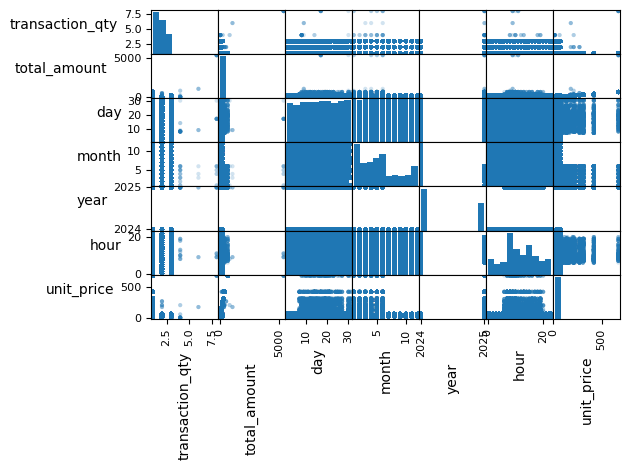

In [52]:
axes = pd.plotting.scatter_matrix(reg_sales_df, alpha=0.2)
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

We are ready to start building our model

In [54]:
X = reg_sales_df.drop(['total_amount'],axis=1)
y = reg_sales_df[['total_amount']]

### Preprocess selected features

You should standardize your input features so the model doesn't inadvertently favor any feature due to its magnitude.
The typical way to do this is to subtract the mean and divide by the standard deviation. Scikit-learn can do this for you.

In [56]:
from sklearn import preprocessing

std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)

In [58]:
pd.DataFrame(X_std).describe().round(2)

,0,1,2,3,4,5
count,376033.00,376033.00,376033.00,376033.00,376033.00,376033.00
mean,0.00,0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.01,-1.69,-1.43,-0.81,-1.98,-1.41
25%,-1.01,-0.89,-0.79,-0.81,-0.61,-0.47
50%,0.29,0.04,-0.15,-0.81,-0.10,-0.14
75%,0.29,0.84,0.80,1.23,0.75,0.24
max,8.06,1.76,2.08,1.23,1.94,23.03


As you can see, a standardized variable has zero mean and a standard deviation of one.

### Create train and test datasets
Randomly split your data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing.

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X_std,y,test_size=0.2,random_state=42)

### Build a multiple linear regression model
Multiple and simple linear regression models can be implemented with exactly the same scikit-learn tools.

In [62]:
# create a model object
regressor = linear_model.LinearRegression()

# train the model in the training data
regressor.fit(X_train, y_train)

# Print the coefficients
coef_ =  regressor.coef_
intercept_ = regressor.intercept_

print ('Coefficients: ',coef_)
print ('Intercept: ',intercept_)

Coefficients:  [[ 3.97804179e+01 -2.21947701e-01  7.69748122e-02 -2.23456948e+00
  -2.30851391e-02  2.85304125e+01]]
Intercept:  [89.88482167]


The Coefficients and Intercept parameters define the best-fit hyperplane to the data. Since there are 6 variables, hence 6 parameters, the hyperplane is a plane. But this best-fit plane will look different in the original, unstandardized feature space. 

You can transform your model's parameters back to the original space prior to standardization as follows. This gives you a proper sense of what they mean in terms of your original input features. Without these adjustments, the model's outputs would be tied to an abstract, transformed space that doesn’t align with the actual independent variables and the real-world problem you’re solving.

In [64]:
# Get the standard scaler's mean and standard deviation parameters
means_ = std_scaler.mean_
std_devs_ = np.sqrt(std_scaler.var_)

# The least squares parameters can be calculated relative to the original, unstandardized feature space as:
coef_original = coef_ / std_devs_
intercept_original = intercept_ - np.sum((means_ * coef_) / std_devs_)

print ('Coefficients: ', coef_original)
print ('Intercept: ', intercept_original)

Coefficients:  [[ 5.15555057e+01 -2.55475245e-02  2.45542697e-02 -4.56816904e+00
  -3.93011256e-03  1.05158982e+00]]
Intercept:  [9193.54055169]


### Print the regression results

Let's calculate the R^2 on the test data:

In [139]:
y_pred_mult_reg = regressor.predict(X_test)
simple_r_score = regressor.score(X_test, y_test)
simple_mse_score = mean_squared_error(y_test, y_pred_mult_reg)
print('MSE score : {0:.3f}'.format(simple_mse_score))
print('R2 score : {0:.3f}'.format(simple_r_score))

MSE score : 762.112
R2 score : 0.741


Now let's see how a regression tree model will perform

Regression Trees are implemented using `DecisionTreeRegressor`.

The important parameters of the model are:

`criterion`: The function used to measure error, we use 'squared_error'.

`max_depth` - The maximum depth the tree is allowed to take; we use 8.

In [75]:
# import the Decision Tree Regression Model from scikit-learn
from sklearn.tree import DecisionTreeRegressor

# for reproducible output across multiple function calls, set random_state to a given integer value
dt_reg = DecisionTreeRegressor(criterion = 'squared_error',
                               max_depth=8, 
                               random_state=35)

In [78]:
dt_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=35)

To evaluate our dataset we will use the `score` method of the `DecisionTreeRegressor` object providing our testing data, this number is the $R^2$ value which indicates the coefficient of determination. We will also evaluate the Mean Squared Error $(MSE)$ of the regression output with respect to the test set target values. High $R^2$ and low $MSE$ values are expected from a good regression model.

In [137]:
# run inference using the sklearn model
y_pred = dt_reg.predict(X_test)

# evaluate mean squared error on the test dataset
r_tree_mse_score = mean_squared_error(y_test, y_pred)
print('MSE score : {0:.3f}'.format(r_tree_mse_score))

r_tree_r2_score = dt_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r_tree_r2_score))

MSE score : 405.211
R^2 score : 0.863


Now let us train some more models which are the XGBoost and Random Forest and see how they performs

### Initialize models
In this step we define the number of base estimators, or individual trees, to be used in each model, and then intialize models for Random Forest regression and XGBoost regression.  We'll just use the default parameters to make the performance comparisons. As a part of the performance comparison, we'll also measure the training times for both models.

In [116]:
# Initialize models
n_estimators=100
rf = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
xgb = XGBRegressor(n_estimators=n_estimators, random_state=42)

In [118]:
# Fit models
# Measure training time for Random Forest
start_time_rf = time.time()
rf.fit(X_train, y_train)
end_time_rf = time.time()
rf_train_time = end_time_rf - start_time_rf

# Measure training time for XGBoost
start_time_xgb = time.time()
xgb.fit(X_train, y_train)
end_time_xgb = time.time()
xgb_train_time = end_time_xgb - start_time_xgb

### We'll Use the fitted models to make predictions on the test set. 
Also, measure the time it takes for each model to make its predictions using the time.time() function to measure the times before and after each model prediction.


In [125]:
# Measure prediction time for Random Forest
start_time_rf = time.time()
y_pred_rf = rf.predict(X_test)
end_time_rf = time.time()
rf_pred_time = end_time_rf - start_time_rf

# Measure prediciton time for XGBoost
start_time_xgb = time.time()
y_pred_xgb = xgb.predict(X_test)
end_time_xgb = time.time()
xgb_pred_time = end_time_xgb - start_time_xgb

We'll now calulate the MSE and R^2 values for both models

In [131]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_rf = r2_score(y_test, y_pred_rf)
r2_xgb = r2_score(y_test, y_pred_xgb)

In [134]:
print(f'Random Forest:  MSE = {mse_rf:.4f}, R^2 = {r2_rf:.4f}')
print(f'      XGBoost:  MSE = {mse_xgb:.4f}, R^2 = {r2_xgb:.4f}')

Random Forest:  MSE = 503.1381, R^2 = 0.8293
      XGBoost:  MSE = 405.1024, R^2 = 0.8625


Print the timings for each model

In [146]:
print(f'Random Forest:  Training Time = {rf_train_time:.3f} seconds, Testing time = {rf_pred_time:.3f} seconds')
print(f'      XGBoost:  Training Time = {xgb_train_time:.3f} seconds, Testing time = {xgb_pred_time:.3f} seconds')

Random Forest:  Training Time = 72.552 seconds, Testing time = 2.487 seconds
      XGBoost:  Training Time = 0.736 seconds, Testing time = 0.040 seconds


Let us print and analyse all of our models so we can choose the best performing model to see the most important features

In [141]:
print(f'    Random Forest:  MSE = {mse_rf:.4f}, R^2 = {r2_rf:.4f}')
print(f'          XGBoost:  MSE = {mse_xgb:.4f}, R^2 = {r2_xgb:.4f}')
print(f'      Random Tree:  MSE = {r_tree_mse_score:.4f}, R^2 = {r_tree_r2_score:.4f}')
print(f'Simple Regression:  MSE = {simple_mse_score:.4f}, R^2 = {simple_r_score:.4f}')

    Random Forest:  MSE = 503.1381, R^2 = 0.8293
          XGBoost:  MSE = 405.1024, R^2 = 0.8625
      Random Tree:  MSE = 405.2109, R^2 = 0.8625
Simple Regression:  MSE = 762.1117, R^2 = 0.7414


From our observation above, XGBoost is our best model. It has a similar R2 score with our Random Tree model but it has a lower MSE and it takes very short time to train thus we'll choose XGBoost to uncover our most important features and thus discover which features we need to focus on the most 

In [159]:
# Feature importances from fitted XGBRegressor
feature_importances = xgb.feature_importances_

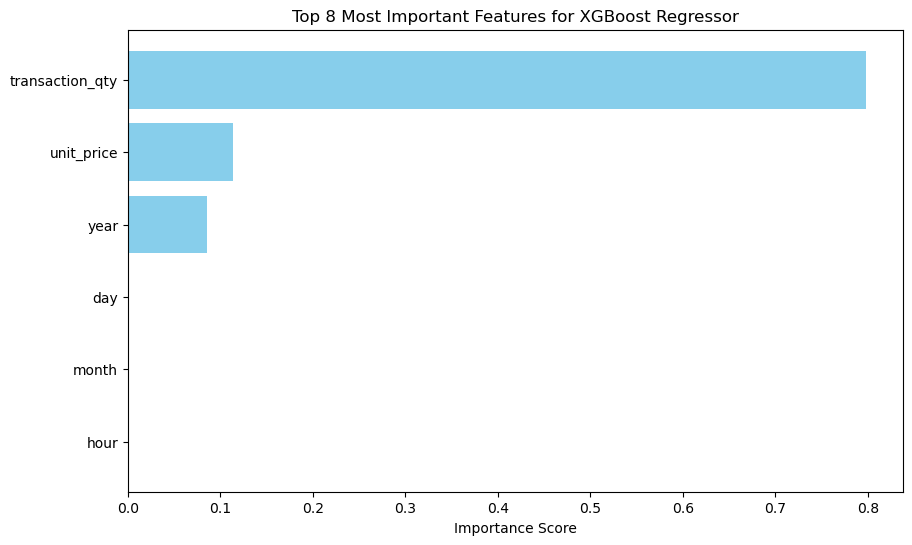

In [163]:
# Feature names (from original DataFrame before scaling)
feature_names = X.columns  

# Build DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot top N
N = 8
top_features = importance_df.head(N)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title(f'Top {N} Most Important Features for XGBoost Regressor')
plt.xlabel('Importance Score')
plt.show()

### Conclusion

The feature importance analysis from the XGBoost Regressor shows that *transaction quantity* is by far the most influential factor in predicting sales revenue. This suggests that our business performance is strongly tied to the volume of products purchased per transaction. The second most important driver is *unit price*, followed by *year* (time trend effects).  

From these results, it is clear that to improve performance, we should focus on strategies that increase the number of items customers buy in each transaction, while also carefully optimizing our pricing strategy. By balancing attractive pricing with initiatives that encourage higher transaction volumes, we can drive both sales growth and overall revenue performance more effectively.


### Recommendations

Based on the findings, the following actions are recommended to boost performance:

1. **Increase Transaction Quantity**  
   - Introduce bundle deals (e.g., “Buy 2 coffees, get 1 at half price”) to encourage customers to purchase more items per visit.  
   - Launch loyalty rewards (e.g., free drink after 10 purchases) to promote repeat transactions with higher volumes.  
   - Offer seasonal promotions (e.g., coffee + any bakery item combos) to increase basket size.

2. **Optimize Pricing Strategy**  
   - Conduct price sensitivity analysis to identify the optimal pricing point that maximizes both sales volume and profit margin.  
   - Consider tiered pricing (small, medium, large sizes) to capture different customer willingness to pay.  
   - Test limited-time discounts to boost traffic during off-peak hours.

3. **Leverage Time Trends**  
   - Since *year* also plays a role, monitor how transaction behavior evolves over time.  
   - Adjust promotions seasonally (e.g., hot drinks in winter, iced drinks in summer).  
   - Use predictive analytics to forecast demand and align inventory/pricing strategies accordingly.

By implementing these strategies, the coffee shop can increase both **transaction quantity** and **revenue**, while maintaining a competitive pricing structure that appeals to customers.
